# **Ampliación del espacio de búsqueda del Hamiltoniano**

In [15]:
%load_ext autoreload
%autoreload 2

from modules import schnorr_lattice as sl
from modules import qaoa

from modules import utils

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

from qiskit_optimization.translators import from_docplex_mp
from qiskit_optimization.converters import QuadraticProgramToQubo
from docplex.mp.model import Model

from math import log2, ceil, floor

import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
seed = 98

## **Caso N = 48567227**

In [17]:
N = 48567227

In [18]:
fiveQubit = sl.schnorrCVP(N, 3, 1, seed)

El numero de bits de N = 48567227 es m = 26
La dimension del reticulo que vamos a tratar es n = 5
La cota smooth que vamos a tomar: 50


In [19]:
cvpinstance = fiveQubit.generate_cvp(10, verbose = True)
cvpResult = fiveQubit.babai_algorithm(cvpinstance, delta = 0.75)
print(f'D = \n{cvpResult.D}\n')
print(f'b_op = \n{cvpResult.b_op}\n')
print(f'res_vector = \n{cvpResult.res_vector}\n')
print(f'step_sign = \n{cvpResult.step_sign}\n')
print(f'weights = \n{cvpResult.weight}\n')

B = 
[ 2 0 0 0 0  693 ]
[ 0 1 0 0 0 1099 ]
[ 0 0 1 0 0 1609 ]
[ 0 0 0 3 0 1946 ]
[ 0 0 0 0 2 2398 ]
t = 
(0, 0, 0, 0, 0, 17698)
D = 
[ -2  4 -5  3  2  2 ]
[ -4 -2  4  3 -4  2 ]
[ -4 -3 -1  6  2 -2 ]
[ -4  3  3 -3 -4 -4 ]
[  4  0 -3  9 -2 -1 ]

b_op = 
[    2     6     2     0     6 17699]

res_vector = 
[-2 -6 -2  0 -6 -1]

step_sign = 
[-1  1  1  1  1]

weights = 
(1255, 2045, -1529, -1837, -693)



In [20]:
def get_bounds(cardinal, step_sign):
    """
        Si step_sign == -1 es porque se ha aproximado hacia arrriba por lo que para x_i = 0 es la aproximacion hacia arriba.
        Nos falta por explorar (carinal/2) hacia abajo y (cadinal/2) -1 hacia arriba de x_i.
        Si step_sign == 1 es porque se ha aproximado hacia abajo por lo que para x_i = 0 es la aproximacion hacia abajo.
        Nos falta por explorar (cardinal/2) - 1 hacia abajo y (cardinal/2) hacia arriba en x_i.

        La función devuelve las cotas superior e inferior de una variable entera
        Si step_sign == -1:
            return (-(cardinal//2), cadinal//2 - 1) 
        Si step_sign == 1:
            return (-(cardinal//2) + 1, cardinal//2)
    """

    return (int(-(cardinal//2) + 0.5 + (step_sign*0.5)), int((cardinal//2) - 0.5 + (step_sign*0.5)))
    

In [21]:
def define_qubo(D, residual_vector, step_signs, n): 
    """
    Genera una instancia de un problema Cuadratico de Qiskit.
    Aqui se va a generar directamente el problema asociada a la funcion QUBO del problema.

    D: Base del retículo LLL reducido.
    residual_vector: vector residual obtenido de restar  t - b_op
    step_signs: step_signs[i] = Sign(mu[i] - c[i]). Permite saber que si se ha aproximado hacia abajo el valor de mu
                                                    explorar la aproximacion hacia arriba de mu, y al reves tambien.
    
    return: QuadraticProgram()                                            

    """

    mdl = Model("quboProblem")

    logn = ceil(log2(n)) #Calculo log(n) par que los intervalos sean de tamaño n

    cardinal = 1 << logn

    limites = [get_bounds(cardinal, step_signs[i]) for i in range(n)]

    z = {i: mdl.integer_var(lb=limites[i][0], ub=limites[i][1], name=f"z_{i}") 
     for i in range(n)}
    
    
    objective = 0

    #Itero sobre los n + 1 elementos de los vectores
    for j in range (n + 1):

        #Realizo la operacion que hay dentro del valor absoluto
        #A cada posicion del vector residual t - bop le resto la suma del signo por la variable z y la posicion en concreto de
        #vector de la base reducida
        aux_ob = residual_vector[j] - mdl.sum([z[i]*D[i, j] for i in range(n)])

        #Lo elevo al cuadrado
        objective += aux_ob * aux_ob
    
    #Lo convierto en un problema de minimizacion
    mdl.minimize(objective)

    #Realizo la conversion de un modelo docplex a un modelo qiskit.
    mod = from_docplex_mp(mdl)
    
    return mod

In [22]:
quadratic_problem = define_qubo(cvpResult.D, cvpResult.res_vector, cvpResult.step_sign, fiveQubit.n)
print(quadratic_problem.prettyprint())

Problem name: quboProblem

Minimize
  62*z_0^2 - 30*z_0*z_1 + 38*z_0*z_2 - 40*z_0*z_3 + 56*z_0*z_4 + 65*z_1^2
  + 48*z_1*z_2 + 42*z_1*z_3 + 10*z_1*z_4 + 70*z_2^2 - 28*z_2*z_3 + 78*z_2*z_4
  + 75*z_3^2 - 80*z_3*z_4 + 111*z_4^2 + 48*z_0 - 68*z_1 - 36*z_2 - 24*z_3
  - 22*z_4 + 81

Subject to
  No constraints

  Integer variables (5)
    -4 <= z_0 <= 3
    -3 <= z_1 <= 4
    -3 <= z_2 <= 4
    -3 <= z_3 <= 4
    -3 <= z_4 <= 4



In [23]:
conv = QuadraticProgramToQubo()

qubo5 = conv.convert(quadratic_problem)

print(qubo5.prettyprint())

Problem name: quboProblem

Minimize
  62*z_0@0^2 + 248*z_0@0*z_0@1 + 496*z_0@0*z_0@2 - 30*z_0@0*z_1@0
  - 60*z_0@0*z_1@1 - 120*z_0@0*z_1@2 + 38*z_0@0*z_2@0 + 76*z_0@0*z_2@1
  + 152*z_0@0*z_2@2 - 40*z_0@0*z_3@0 - 80*z_0@0*z_3@1 - 160*z_0@0*z_3@2
  + 56*z_0@0*z_4@0 + 112*z_0@0*z_4@1 + 224*z_0@0*z_4@2 + 248*z_0@1^2
  + 992*z_0@1*z_0@2 - 60*z_0@1*z_1@0 - 120*z_0@1*z_1@1 - 240*z_0@1*z_1@2
  + 76*z_0@1*z_2@0 + 152*z_0@1*z_2@1 + 304*z_0@1*z_2@2 - 80*z_0@1*z_3@0
  - 160*z_0@1*z_3@1 - 320*z_0@1*z_3@2 + 112*z_0@1*z_4@0 + 224*z_0@1*z_4@1
  + 448*z_0@1*z_4@2 + 992*z_0@2^2 - 120*z_0@2*z_1@0 - 240*z_0@2*z_1@1
  - 480*z_0@2*z_1@2 + 152*z_0@2*z_2@0 + 304*z_0@2*z_2@1 + 608*z_0@2*z_2@2
  - 160*z_0@2*z_3@0 - 320*z_0@2*z_3@1 - 640*z_0@2*z_3@2 + 224*z_0@2*z_4@0
  + 448*z_0@2*z_4@1 + 896*z_0@2*z_4@2 + 65*z_1@0^2 + 260*z_1@0*z_1@1
  + 520*z_1@0*z_1@2 + 48*z_1@0*z_2@0 + 96*z_1@0*z_2@1 + 192*z_1@0*z_2@2
  + 42*z_1@0*z_3@0 + 84*z_1@0*z_3@1 + 168*z_1@0*z_3@2 + 10*z_1@0*z_4@0
  + 20*z_1@0*z_4@1 + 40*z_1@0*z_4@2 +

In [24]:
print("Variables en QUBO:")
for i, var in enumerate(qubo5.variables):
    print(f"  Índice {i}: {var.name} (tipo: {var.vartype})")

Variables en QUBO:
  Índice 0: z_0@0 (tipo: VarType.BINARY)
  Índice 1: z_0@1 (tipo: VarType.BINARY)
  Índice 2: z_0@2 (tipo: VarType.BINARY)
  Índice 3: z_1@0 (tipo: VarType.BINARY)
  Índice 4: z_1@1 (tipo: VarType.BINARY)
  Índice 5: z_1@2 (tipo: VarType.BINARY)
  Índice 6: z_2@0 (tipo: VarType.BINARY)
  Índice 7: z_2@1 (tipo: VarType.BINARY)
  Índice 8: z_2@2 (tipo: VarType.BINARY)
  Índice 9: z_3@0 (tipo: VarType.BINARY)
  Índice 10: z_3@1 (tipo: VarType.BINARY)
  Índice 11: z_3@2 (tipo: VarType.BINARY)
  Índice 12: z_4@0 (tipo: VarType.BINARY)
  Índice 13: z_4@1 (tipo: VarType.BINARY)
  Índice 14: z_4@2 (tipo: VarType.BINARY)


In [25]:
Hc, offset = qaoa.define_hamiltonian(qubo5)
print(f'Offset = {offset}')
print(f'Hamiltonian = \n{Hc}')

Offset = 2100.0
Hamiltonian = 
SparsePauliOp(['IIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIZI', 'IIIIIIIIIIIIZII', 'IIIIIIIIIIIZIII', 'IIIIIIIIIIZIIII', 'IIIIIIIIIZIIIII', 'IIIIIIIIZIIIIII', 'IIIIIIIZIIIIIII', 'IIIIIIZIIIIIIII', 'IIIIIZIIIIIIIII', 'IIIIZIIIIIIIIII', 'IIIZIIIIIIIIIII', 'IIZIIIIIIIIIIII', 'IZIIIIIIIIIIIII', 'ZIIIIIIIIIIIIII', 'IIIIIIIIIIIIIZZ', 'IIIIIIIIIIIIZIZ', 'IIIIIIIIIIIZIIZ', 'IIIIIIIIIIZIIIZ', 'IIIIIIIIIZIIIIZ', 'IIIIIIIIZIIIIIZ', 'IIIIIIIZIIIIIIZ', 'IIIIIIZIIIIIIIZ', 'IIIIIZIIIIIIIIZ', 'IIIIZIIIIIIIIIZ', 'IIIZIIIIIIIIIIZ', 'IIZIIIIIIIIIIIZ', 'IZIIIIIIIIIIIIZ', 'ZIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIZZI', 'IIIIIIIIIIIZIZI', 'IIIIIIIIIIZIIZI', 'IIIIIIIIIZIIIZI', 'IIIIIIIIZIIIIZI', 'IIIIIIIZIIIIIZI', 'IIIIIIZIIIIIIZI', 'IIIIIZIIIIIIIZI', 'IIIIZIIIIIIIIZI', 'IIIZIIIIIIIIIZI', 'IIZIIIIIIIIIIZI', 'IZIIIIIIIIIIIZI', 'ZIIIIIIIIIIIIZI', 'IIIIIIIIIIIZZII', 'IIIIIIIIIIZIZII', 'IIIIIIIIIZIIZII', 'IIIIIIIIZIIIZII', 'IIIIIIIZIIIIZII', 'IIIIIIZIIIIIZII', 'IIIIIZIIIIIIZII', 'IIIIZIIIIIIIZII', 'III

In [26]:
nHc, _= qaoa.normalize_hamiltonian(Hc)
print(f'Hamiltonian = \n{nHc}')

Hamiltonian = 
SparsePauliOp(['IIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIZI', 'IIIIIIIIIIIIZII', 'IIIIIIIIIIIZIII', 'IIIIIIIIIIZIIII', 'IIIIIIIIIZIIIII', 'IIIIIIIIZIIIIII', 'IIIIIIIZIIIIIII', 'IIIIIIZIIIIIIII', 'IIIIIZIIIIIIIII', 'IIIIZIIIIIIIIII', 'IIIZIIIIIIIIIII', 'IIZIIIIIIIIIIII', 'IZIIIIIIIIIIIII', 'ZIIIIIIIIIIIIII', 'IIIIIIIIIIIIIZZ', 'IIIIIIIIIIIIZIZ', 'IIIIIIIIIIIZIIZ', 'IIIIIIIIIIZIIIZ', 'IIIIIIIIIZIIIIZ', 'IIIIIIIIZIIIIIZ', 'IIIIIIIZIIIIIIZ', 'IIIIIIZIIIIIIIZ', 'IIIIIZIIIIIIIIZ', 'IIIIZIIIIIIIIIZ', 'IIIZIIIIIIIIIIZ', 'IIZIIIIIIIIIIIZ', 'IZIIIIIIIIIIIIZ', 'ZIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIZZI', 'IIIIIIIIIIIZIZI', 'IIIIIIIIIIZIIZI', 'IIIIIIIIIZIIIZI', 'IIIIIIIIZIIIIZI', 'IIIIIIIZIIIIIZI', 'IIIIIIZIIIIIIZI', 'IIIIIZIIIIIIIZI', 'IIIIZIIIIIIIIZI', 'IIIZIIIIIIIIIZI', 'IIZIIIIIIIIIIZI', 'IZIIIIIIIIIIIZI', 'ZIIIIIIIIIIIIZI', 'IIIIIIIIIIIZZII', 'IIIIIIIIIIZIZII', 'IIIIIIIIIZIIZII', 'IIIIIIIIZIIIZII', 'IIIIIIIZIIIIZII', 'IIIIIIZIIIIIZII', 'IIIIIZIIIIIIZII', 'IIIIZIIIIIIIZII', 'IIIZIIIIIIIIZII', '

In [27]:
circuit = qaoa.construct_circuit(nHc, reps= 3)

In [28]:
monitor, optParameters = qaoa.qaoa_algorithm(circuit, nHc, min_method = 'COBYLA')

KeyboardInterrupt: 

In [ ]:
print(optParameters)

{'β[0]': np.float64(0.36445723181526163), 'β[1]': np.float64(0.19622860150757684), 'β[2]': np.float64(0.13473839496414144), 'γ[0]': np.float64(-0.2713591198109556), 'γ[1]': np.float64(-0.6532037979004823), 'γ[2]': np.float64(-0.9318554130389246)}


In [ ]:
angulos = [-0.6940314002532073, -0.4312340097736813, -0.20336951745319942, 0.44130710896540093, 0.9690937307369647, 1.81236712440056]

In [ ]:
results = qaoa.sample_from_parameters(circuit, list(optParameters.values()), shots = 1_000_000)
#results = qaoa.sample_from_parameters(circuit, angulos, shots = 1_000_000)

print(len(results))
for bitstring, count in results.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

21092
Bistring: 100011011011011 -> Counts: 1550
Bistring: 011011011011011 -> Counts: 1531
Bistring: 011100011011100 -> Counts: 1531
Bistring: 100011011011100 -> Counts: 1509
Bistring: 011011011011100 -> Counts: 1493
Bistring: 011100011011101 -> Counts: 1460
Bistring: 011100011011011 -> Counts: 1439
Bistring: 100011010011100 -> Counts: 1401
Bistring: 100100011011011 -> Counts: 1389
Bistring: 100100010100011 -> Counts: 1386
Bistring: 011100100010100 -> Counts: 1357
Bistring: 100100011100011 -> Counts: 1356
Bistring: 100100011011100 -> Counts: 1355
Bistring: 011010011011011 -> Counts: 1344
Bistring: 100011010100011 -> Counts: 1325
Bistring: 011100100011100 -> Counts: 1314
Bistring: 100011010011011 -> Counts: 1313
Bistring: 100100010100100 -> Counts: 1308
Bistring: 100100010011100 -> Counts: 1305
Bistring: 011100100100100 -> Counts: 1303
Bistring: 011010011100011 -> Counts: 1264
Bistring: 011011100011100 -> Counts: 1253
Bistring: 100100100010100 -> Counts: 1232
Bistring: 100100100010011 ->

In [ ]:
bitstrings = sl.bitstrings2vector(list(results.keys()))


In [ ]:
combinacion = [conv.interpret(bit_vector).astype(int).tolist() for bit_vector in bitstrings]
print(combinacion)

[[-1, 0, 0, 0, 1], [-1, 0, 0, 0, 0], [0, 0, 0, 1, 0], [0, 0, 0, 0, 1], [0, 0, 0, 0, 0], [1, 0, 0, 1, 0], [-1, 0, 0, 1, 0], [0, 0, -1, 0, 1], [-1, 0, 0, 1, 1], [-1, 1, -1, 1, 1], [0, -1, 1, 1, 0], [-1, 1, 0, 1, 1], [0, 0, 0, 1, 1], [-1, 0, 0, -1, 0], [-1, 1, -1, 0, 1], [0, 0, 1, 1, 0], [-1, 0, -1, 0, 1], [0, 1, -1, 1, 1], [0, 0, -1, 1, 1], [0, 1, 1, 1, 0], [-1, 1, 0, -1, 0], [0, 0, 1, 0, 0], [0, -1, 1, 1, 1], [-1, -1, 1, 1, 1], [-1, -1, 0, 1, 1], [0, 0, 0, -1, 0], [0, 0, 1, 1, 1], [0, 1, -1, 0, 1], [1, 1, 0, 1, 0], [-1, -1, 0, 1, 0], [-2, 0, 0, 0, 1], [-1, -1, 1, 1, 0], [1, 1, -1, 1, 1], [0, 1, -2, 1, 1], [-1, 1, 0, 0, 1], [1, 1, 1, 1, 0], [0, 1, 0, 1, 1], [-1, 1, 1, 1, 1], [0, 1, -2, 0, 1], [0, -1, 0, 1, 1], [-2, 0, 1, 0, 1], [1, 1, -2, 1, 1], [-1, 0, 1, 0, 1], [-1, 1, -2, 0, 1], [-1, 1, 1, 1, 0], [0, 1, 0, 1, 0], [-2, -1, 1, 0, 1], [-1, 1, 1, -1, -1], [-1, 1, 1, 0, 0], [-1, 1, 1, -1, 0], [-1, -1, 2, 1, 0], [-1, 1, 0, 0, 0], [-2, -1, 1, 1, 1], [1, 0, 0, 0, 0], [0, 1, 1, 1, 1], [0, -1, 

In [ ]:
nD = sl.integer_to_matrix(cvpResult.D)
movement = combinacion @ nD

vnews = cvpResult.b_op + movement 

In [ ]:
distances = utils.get_distances(vnews, cvpinstance.t)

In [ ]:
nB = sl.integer_to_matrix(cvpinstance.B)
uv_pairs = sl.vectors2uv_pairs(nB, vnews, fiveQubit.n)
for pair5 in uv_pairs:
    print(pair5)

[48510000 1]
[340312500 7]
[676603125 14]
[242045496 5]
[48514950 1]
[192913083 4]
[2373046875 49]
[48498912 1]
[531562500 11]
[711914062500 14641]
[96059601 2]
[64599609375 1331]
[48223350 1]
[146410000 3]
[5906250000 121]
[385914375 8]
[48600000 1]
[64584843750 1331]
[531441000 11]
[1550390625 32]
[1323437500 27]
[96850215 2]
[5990626026 125]
[48024900 1]
[48114000 1]
[243509112 5]
[96268095 2]
[535815000 11]
[775018125 16]
[16539187500 343]
[437500000 9]
[336909375 7]
[5859137025 121]
[4982259375000 102487]
[535937500 11]
[3094331625 64]
[11720953125 242]
[23447265625 484]
[5904900000 121]
[1200348072 25]
[11790625000 243]
[64570081500 1331]
[145260500 3]
[455625000000 9317]
[8544921875 176]
[4271484375 88]
[1304380000 27]
[142978515625 2916]
[5263671875 108]
[35666640625 729]
[192163125 4]
[48828125 1]
[48125000 1]
[6051754863 125]
[4254271875 88]
[2357826570 49]
[193359375 4]
[340122240 7]
[2717735625 56]
[35870450000 729]
[1195408368 25]
[3522990625 72]
[241049424 5]
[48299328 1]

In [ ]:
sr_pairs = sl.uv_pairs2sr_pairs(uv_pairs, fiveQubit)
print(sr_pairs)

[((96850215, 2), -284239), ((5859137025, 121), -17497442), ((48828125, 1), 260898), ((193359375, 4), -909533), ((145578125, 3), -123556), ((48234375, 1), -332852), ((47832147, 1), -735080), ((97435855, 2), 301401), ((48914250, 1), 347023), ((49116375, 1), 549148), ((11789738455, 243), -12097706), ((52301766015, 1078), -53704691), ((1214383104, 25), 202429), ((47436840, 1), -1130387), ((18983603961, 400), -443286839), ((11832128000, 243), 30291839), ((237105792, 5), -5730343), ((198966796875, 4096), 35435083), ((2408693760, 49), 28899637), ((242121642, 5), -714493), ((1213857792, 25), -322883), ((12332586896091, 256000), -100623215909), ((96889010407, 1980), 725900947), ((685084833125, 13824), 13691487077), ((47059600, 1), -1507627)]


In [ ]:
probs = utils.get_probs(results.values(), shots = 1_000_000)

In [ ]:
utils.prettyprint(vnews, distances, probs, cvpResult.b_op, cvpResult.res_vector)

Vector más corto por algoritmo de Babai: 
b_op = [    2     6     2     0     6 17699]

El vector residual 
t - b_op = [-2 -6 -2  0 -6 -1]

La distancia |t - b_op| = 9.000

0: Prob = 0.00155
	vnew = [    8     2     4     6     2 17696] con distancia: 11.314
1: Prob = 0.00153
	vnew = [    4     2     7    -3     4 17697] con distancia: 9.747
2: Prob = 0.00153
	vnew = [   -2     9     5    -3     2 17695] con distancia: 11.489
3: Prob = 0.00151
	vnew = [    6     6    -1     9     4 17698] con distancia: 13.038
4: Prob = 0.00149
	vnew = [    2     6     2     0     6 17699] con distancia: 9.000
5: Prob = 0.00146
	vnew = [   -4    13     0     0     4 17697] con distancia: 14.213
6: Prob = 0.00144
	vnew = [    0     5    10    -6     0 17693] con distancia: 13.638
7: Prob = 0.00140
	vnew = [   10     9     0     3     2 17700] con distancia: 14.071
8: Prob = 0.00139
	vnew = [    4     5     7     3    -2 17692] con distancia: 11.790
9: Prob = 0.00139
	vnew = [    4     6    12     0    -

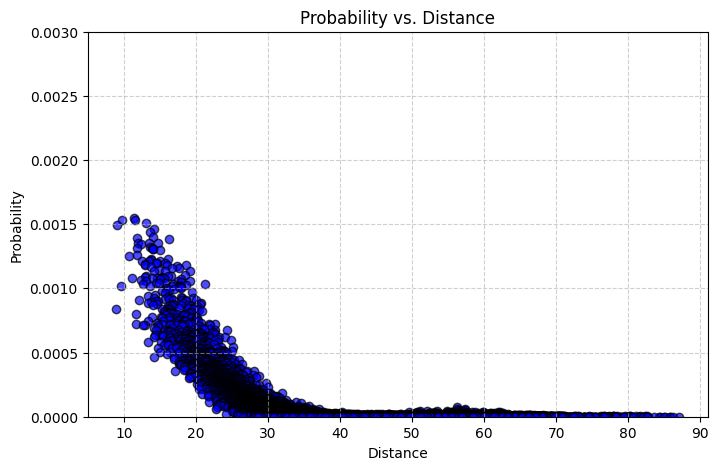

In [ ]:
plt.figure(figsize=(8, 5))

# Creating the scatter plot
plt.scatter(distances, probs, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.003) 

plt.grid(True, linestyle='--', alpha=0.6)
#plt.savefig("figures/5QubitCase_ProbsDistances.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
def obtain_data(vnews, instance, b_op, N, n, bitlength,
                probs):

    #Calculo el modulo al cuadrado para comparar las distancias obtenidas
    distances = utils.get_distances2(vnews, instance.t)

    #Calculo la distancia del vector aproximado obtenido clasicamente
    res_vector = np.subtract(b_op, instance.t)
    aprox_distance = np.dot(res_vector, res_vector)

    #Inicializo las variables para vector mas cercano encontrado, vectores simulares al aproximado y vectores mas cortos que el aproximado
    best_distance_prob = 0
    best_distance = np.inf

    aprox_sol_prob = 0

    improve_prob = 0

    for i in range(len(vnews)):

        if distances[i] == aprox_distance: 
            aprox_sol_prob += probs[i]

        if distances[i] < aprox_distance:
            improve_prob += probs[i]
        
        if distances[i] < best_distance:
            best_distance_prob = probs[i]
            best_distance = distances[i]
        elif distances[i] == best_distance: 
            best_distance_prob += probs[i]

    
    return pd.DataFrame({
        'Bit_length':[bitlength],
        'N': [N],
        'Lattice_dimension': [n],
        '|b_op - t|^2': [aprox_distance],
        '|vbest - t|^2': [best_distance],
        'P(b_op)': [aprox_sol_prob],
        'P(vbest)': [best_distance_prob],
        'P(|vnew - t|^2 < |b_op - t|^2)': [improve_prob],
        'P(|vnew - t|^2 <= |b_op - t|^2)': [improve_prob + aprox_sol_prob],
        'P(|vnew - t|^2 > |b_op - t|^2)' : [1 - (improve_prob + aprox_sol_prob)]
    })

In [ ]:
df = obtain_data(vnews, cvpinstance, cvpResult.b_op, N, fiveQubit.n, fiveQubit.m, probs)

print(df.to_string())

   Bit_length         N  Lattice_dimension  |b_op - t|^2  |vbest - t|^2   P(b_op)  P(vbest)  P(|vnew - t|^2 < |b_op - t|^2)  P(|vnew - t|^2 <= |b_op - t|^2)  P(|vnew - t|^2 > |b_op - t|^2)
0          26  48567227                  5            81             78  0.001493  0.000842                        0.000842                         0.002335                        0.997665


## **Caso N = 261980999226229**